# Comparing interatomic potentials for dislocations in fcc Ni

**Resources**
* [Google Colab](https://colab.research.google.com/): the intended platform to run this tutorial. It needs only a browser and a Google account.
* [LAMMPS examples](https://github.com/lammps/lammps/tree/develop/examples): input scripts for many other simulation types, if you want to see more examples.
* [LAMMPS manual](https://docs.lammps.org/Manual.html): the full documentation of every command used in `scripts/`, for further reading.
* [NIST Interatomic Potentials Repository](https://www.ctcms.nist.gov/potentials/): collection of interatomic potentials, where you can get new ones to test with this notebook.

**Benchmark chain**

| Step | Quantity | Tool |
|---|---|---|
| 1 | lattice parameter $a_0$ | LAMMPS (`a0_full.in` or `a0.in`) |
| 2 | Burgers vectors $b$, $b_p$ | Python |
| 3 | elastic constants $C_{11}, C_{12}, C_{44}$ | LAMMPS (`elastic_full.in` or `elastic.in`) |
| 4 | shear modulus $\mu$ on the slip system | Python ($C_{ijkl}n_im_jn_km_l$) |
| 5 | generalized stacking-fault (γ) surface, $\gamma_{usf}$, $\gamma_{isf}$ | atomman `StackingFault` + LAMMPS (`gsf.in`) |
| 6 | equilibrium partial separation $d_{sf}$ | Python ($\mu b^2/12\pi\gamma_{sf}$) |
| 7 | periodic array of dislocations (PAD), partial separation | atomman `Dislocation` + LAMMPS (`pad.in`) + OVITO (CNA) |
| 8 | critical resolved shear stress (CRSS) of the PAD | LAMMPS (`crss.in`) |
| 9 | disregistry of the PAD | atomman `disregistry` |

## 0. Setup
### 0.1 Install (Google Colab)
The Python packages all come from PyPI, so nothing needs compiling. LAMMPS runs as a **single serial process**.

In [ ]:
%pip install -q "lammps[mpi]==2025.7.22.4.0" "atomman==1.5.4" "ase==3.29.0" "ovito==3.16.1"
!apt-get -qq update > /dev/null && apt-get -qq install -y mesa-vulkan-drivers > /dev/null   # software Vulkan driver, needed by OVITO's renderer

### 0.2 Imports

In [ ]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

# The LAMMPS wheel links against MPICH's libmpi.so.12, which pip installs outside the loader's search path
# (on Colab: /usr/local/lib, whose loader cache is not refreshed). Load it explicitly before importing lammps;
# also export its folder so that `!lmp ...` shell cells find it.
import os, ctypes, importlib.metadata
_libmpi = next(f.locate().resolve() for f in importlib.metadata.files('mpich') if f.name == 'libmpi.so.12')
ctypes.CDLL(str(_libmpi), mode=ctypes.RTLD_GLOBAL)
os.environ['LD_LIBRARY_PATH'] = f"{_libmpi.parent}:{os.environ.get('LD_LIBRARY_PATH', '')}"

import lammps
from lammps import lammps as LAMMPS

import atomman as am
import atomman.unitconvert as uc

import ase, ase.build, ase.io
import ovito, ovito.gui, ipywidgets
from ovito.io.ase import ase_to_ovito
from ovito.pipeline import Pipeline, StaticSource
from ovito.modifiers import (CommonNeighborAnalysisModifier as CNA, ExpressionSelectionModifier,
                             DeleteSelectedModifier, ComputePropertyModifier)
from ovito.vis import Viewport, TachyonRenderer

print('LAMMPS', LAMMPS(cmdargs=['-screen', 'none', '-log', 'none']).version(), '| atomman', am.__version__,
      '| ASE', ase.__version__, '| OVITO', ovito.version_string)

### 0.3 Tutorial files
The potential files (`ni_potentials/`) and the LAMMPS scripts (`scripts/`) come from the course repository,
[github.com/e-rodaro/multi_scale_md_tutorial](https://github.com/TheNewPing/multi_scale_md_tutorial).
The cell below downloads the repository as a zip archive and extracts only these two folders into the current
directory, so it needs neither `git` nor a GitHub account.

* A folder that already exists is **not** downloaded again. This keeps any edits you made, and it means the cell
  does nothing when you run the notebook from a local clone of the repository.
* To discard your edits and get a fresh copy, run `fetch_course_files(force=True)`.

In [ ]:
import io, shutil, urllib.error, urllib.request, zipfile

REPO, BRANCH = 'TheNewPing/multi_scale_md_tutorial', 'master'
FOLDERS      = ['ni_potentials', 'scripts']        # extracted into the current directory

def fetch_course_files(folders=FOLDERS, repo=REPO, branch=BRANCH, force=False):
    todo = [f for f in folders if force or not Path(f).is_dir()]
    if not todo:
        print('already present:', ', '.join(f'{f}/' for f in folders))
        return
    url = f'https://github.com/{repo}/archive/refs/heads/{branch}.zip'
    try:
        with urllib.request.urlopen(url) as r:
            zf = zipfile.ZipFile(io.BytesIO(r.read()))
    except urllib.error.HTTPError as e:
        raise RuntimeError(f'download of {url} failed (HTTP {e.code}); is the repository public?') from None
    root = zf.namelist()[0].split('/')[0]           # GitHub puts everything under '<repo>-<branch>/'
    for folder in todo:
        members = [m for m in zf.namelist() if m.startswith(f'{root}/{folder}/') and not m.endswith('/')]
        if not members:
            print(f'WARNING: {folder}/ is not in {repo}@{branch}')
            continue
        shutil.rmtree(folder, ignore_errors=True)
        for m in members:
            dest = Path(m[len(root) + 1:])
            dest.parent.mkdir(parents=True, exist_ok=True)
            dest.write_bytes(zf.read(m))
        print(f'{folder}/:', ', '.join(sorted(str(Path(m).relative_to(f"{root}/{folder}")) for m in members)))

fetch_course_files()

WORK = Path('work'); WORK.mkdir(exist_ok=True)     # data files and logs; the LAMMPS scripts are in scripts/

# Let LAMMPS also find the potential files that ship with the wheel by name (e.g. Ni_u3.eam)
os.environ['LAMMPS_POTENTIALS'] = str(Path(lammps.__file__).parent / 'share' / 'lammps' / 'potentials')

### 0.4 The interatomic potential: `potential.mod`
Every LAMMPS script reads the potential from one small file with `include ${potential_file}`, after the box has been created.
**To test a different potential, edit this file (or write another one) and re-run the notebook. Nothing else changes.**

A `.mod` file holds ordinary LAMMPS commands:

| line | meaning | what to change |
|---|---|---|
| `pair_style eam/alloy` | functional form of the potential | `eam/alloy` for setfl files (`*.eam.alloy`), `eam/fs` for Finnis–Sinclair setfl files, `eam` for single-element funcfl files (`*.eam`), `meam`, `snap`, … |
| `pair_coeff * * <file> Ni` | parameter file, then one element name per atom type | the file path; the element as it is named in that file. Every structure in this notebook has **one** atom type, so there is a single `Ni`. For `pair_style eam` the element name is omitted (`pair_coeff * * Ni_u3.eam`). |
| `mass * 58.6934` | atomic mass of every type (g/mol) | nothing; it plays no role in static relaxations |

In [ ]:
%%writefile potential.mod
# Ni, EAM: Y. Mishin, Acta Mater. 52, 1451 (2004)
pair_style   eam/alloy
pair_coeff   * * ni_potentials/NiAl_Mishin_2004.eam.alloy.in Ni
mass         * 58.6934

**Optional: use your own potential file (Colab).** Run the cell below and pick the file(s) in the dialog. Uploaded files are saved in the current folder.

In [ ]:
# from google.colab import files
# uploaded = files.upload()
# print('uploaded:', list(uploaded))

### 0.5 Running a LAMMPS script from Python
Every step uses the `lammps` Python module in the same four calls:
```python
L = LAMMPS(cmdargs=['-screen', 'none', '-var', 'potential_file', 'potential.mod', '-var', 'data_file', 'work/a0.data'])
L.file('scripts/a0.in')            # run the script
lx = L.extract_variable('lx')      # read a LAMMPS variable back into Python
L.close()
```
`cmdargs` are the command-line flags of `lmp`: `-var name value` sets a script input, and `-screen none` keeps LAMMPS's own output
(thermo tables, minimizer statistics) out of the notebook. The full output is still written to `log.lammps`.
Structures come back as files: scripts that relax a structure end with `write_data ${out_file}`, and the notebook reads that file with ASE (0.6).

**Conventions shared by all scripts**
* Each script uses `include ${potential_file}` after the box is created, so the scripts themselves are independent of the potential.
* Scripts declare their inputs as `variable <name> index <default>`. A value passed with `-var` takes precedence, so every script can also be run on its own.
* Units are `metal` throughout.

### 0.6 Structures: ASE in and out of LAMMPS, OVITO for analysis and pictures
Every structure in the notebook is an ASE `Atoms` object, and it moves to and from LAMMPS as a data file:
* `atoms.write(path, format='lammps-data')` writes the file that a script reads with `read_data ${data_file}`.
* `ase.io.read(path, format='lammps-data')` reads the file that a script wrote with `write_data ${out_file}`, with the atoms sorted by LAMMPS id.
  A data file stores no boundary conditions, and ASE makes all three directions periodic. For a slab or the dislocation cell, set `atoms.pbc` afterwards.
* atomman builds the defect structures (stacking-fault slab, dislocation); `system.dump('ase_Atoms')` converts them to ASE.

The OVITO helpers below build the pictures:

| helper | what it does |
|---|---|
| `pipeline(atoms, *modifiers)` | an OVITO pipeline on the structure; `.compute()` returns the analysed data |
| `render(structures, titles, modifiers, view)` | draws one or more structures side by side as images |
| `animate(frames, labels, show_surfaces=True, show_bulk=False)` | an interactive animation of a list of structures (e.g. a trajectory) in one OVITO widget: ▶ plays it, the slider picks a frame. Atoms are coloured by CNA; the defect is always shown, the free surfaces and the fcc bulk (drawn see-through) on request (Sections 7 and 8) |
| `view3d(atoms, *modifiers, picking=False)` | an interactive 3D view (OVITO Jupyter widget): drag to rotate, scroll to zoom. |

The analysis uses one OVITO modifier, `CNA()`: adaptive common neighbour analysis. Each atom gets a `Structure Type`: 0 other, 1 fcc, 2 hcp, 3 bcc, 4 icosahedral. Default colours: fcc green, hcp red, bcc blue, other white.

In [ ]:
def pipeline(atoms, *modifiers, show_cell=True):
    data = ase_to_ovito(atoms)
    data.cell.vis.enabled = show_cell     # without the cell outline, zoom_all() fits the atoms
    p = Pipeline(source=StaticSource(data=data))
    for m in modifiers:
        p.modifiers.append(m)
    return p

def structure_counts(data):
    t = np.asarray(data.particles['Structure Type'])
    return {CNA.Type(k).name.lower(): int((t == k).sum()) for k in np.unique(t)}

def render(structures, titles=None, modifiers=(), view='Ortho', size=(640, 480), show_cell=True, camera_dir=None):
    # view: an OVITO viewport type - 'Top' looks down z, 'Front' along y, 'Left' along x, 'Ortho' is oblique
    # show_cell=False: no cell outline, and the camera frames only the atoms left after the modifiers
    # camera_dir: optional viewing direction (x, y, z), overrides the one given by `view`
    structures = list(structures) if isinstance(structures, (list, tuple)) else [structures]
    fig, axes = plt.subplots(1, len(structures), figsize=(5.5 * len(structures), 4.5), squeeze=False)
    for k, (atoms, ax) in enumerate(zip(structures, axes[0])):
        for p in list(ovito.scene.pipelines):          # one structure in the scene at a time
            p.remove_from_scene()
        p = pipeline(atoms, *modifiers, show_cell=show_cell)
        p.add_to_scene()
        vp = Viewport(type=getattr(Viewport.Type, view))
        if camera_dir is not None:
            vp.camera_dir = camera_dir
        vp.zoom_all()
        if not show_cell:                              # close-up: frame the atoms that are left after the modifiers
            pos = np.asarray(p.compute().particles.positions)
            vp.camera_pos = (pos.min(0) + pos.max(0)) / 2
            vp.fov = 0.6 * np.ptp(pos, axis=0).max()   # half-size of the visible area, Å (orthographic views)
        png = WORK / f'render_{k}.png'
        vp.render_image(filename=str(png), size=size, renderer=TachyonRenderer())
        p.remove_from_scene()
        ax.imshow(plt.imread(png)); ax.axis('off')
        title = titles[k] if titles else ''
        data = p.compute()
        if 'Structure Type' in data.particles:
            title += '\n' + ', '.join(f'{n}: {c}' for n, c in structure_counts(data).items())
        ax.set_title(title, fontsize=9)
    plt.show()

def view3d(atoms, *modifiers, height='450px', picking=False):
    scene = ovito.Scene()                      # a scene of its own, so later render() calls do not clear this view
    scene.pipelines.append(pipeline(atoms, *modifiers))
    vp = Viewport(scene=scene.scene_root, type=Viewport.Type.Perspective)
    vp.zoom_all()
    # picking=True: hover over an atom to see its properties. Off by default, because some browsers then show a blank view
    return ovito.gui.create_ipywidget(vp, picking=picking, layout=ipywidgets.Layout(width='100%', height=height))

def animate(frames, labels, *modifiers, show_surfaces=True, show_bulk=False, surface_width=5.0, bulk_transparency=0.97,
            camera_dir=(0.35, -1, -0.45), interval=200, height='450px'):
    # frames: list of ASE Atoms (e.g. a trajectory) of a slab with free surfaces along y; labels: one text per frame
    # Atoms are coloured by CNA and fall into three groups:
    #   defect:   non-fcc atoms inside the slab, e.g. the dislocation (always shown)
    #   surfaces: non-fcc atoms within surface_width (Å) of the top or bottom of the slab (show_surfaces)
    #   bulk:     fcc atoms (show_bulk); drawn see-through (bulk_transparency: 0 opaque ... 1 invisible) so the defect stays visible
    # Extra OVITO modifiers are applied after these. The camera looks along camera_dir and frames the atoms shown in the
    # first frame. Scroll to zoom, drag to rotate.
    y = frames[0].positions[:, 1]
    y_bottom, y_top = y.min() + surface_width, y.max() - surface_width
    hidden = []                                # OVITO expressions for the atoms to remove
    if not show_bulk:
        hidden.append('StructureType == 1')
    if not show_surfaces:
        hidden.append(f'StructureType != 1 && (Position.Y < {y_bottom} || Position.Y > {y_top})')
    shown = [CNA()]
    if hidden:
        shown += [ExpressionSelectionModifier(expression=' || '.join(f'({h})' for h in hidden)), DeleteSelectedModifier()]
    if show_bulk:
        shown.append(ComputePropertyModifier(output_property='Transparency',
                                             expressions=[f'StructureType == 1 ? {bulk_transparency} : 0']))

    p = pipeline(frames[0], *shown, *modifiers, show_cell=False)
    scene = ovito.Scene()                      # a scene of its own, like view3d
    scene.pipelines.append(p)
    vp = Viewport(scene=scene.scene_root, type=Viewport.Type.Ortho, camera_dir=camera_dir)
    pos = np.asarray(p.compute().particles.positions)
    vp.camera_pos = (pos.min(0) + pos.max(0)) / 2
    vp.fov = 0.35 * np.ptp(pos, axis=0).max()
    viewer = ovito.gui.create_ipywidget(vp, layout=ipywidgets.Layout(width='100%', height=height))
    slider = ipywidgets.IntSlider(value=0, min=0, max=len(frames) - 1, description='frame')
    play = ipywidgets.Play(value=0, min=0, max=len(frames) - 1, interval=interval)
    ipywidgets.link((play, 'value'), (slider, 'value'))   # linked in Python: jslink (browser-only) does nothing on Colab
    info = ipywidgets.Label()

    def show(change=None):
        data = ase_to_ovito(frames[slider.value])
        data.cell.vis.enabled = False
        p.source.data = data                   # swap the structure, keep the modifiers and the camera
        viewer.refresh()
        info.value = labels[slider.value]

    slider.observe(show, 'value')
    show()
    return ipywidgets.VBox([ipywidgets.HBox([play, slider]), info, viewer])

try:                                    # Colab shows third-party widgets only after this call
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:
    pass

## 1. Lattice parameter $a_0$
ASE builds an `NCELL_A0`³ fcc supercell at a guessed lattice parameter, then relaxed at zero pressure.

**Script contract - `a0[_full].in`**

| in (`-var`) | out (`extract_variable`) |
|---|---|
| `data_file`, `out_file` | `lx` [Å] (relaxed box length), `Ecoh` [eV/atom]; relaxed cell in `out_file` |

In [ ]:
A_GUESS = 3.52
NCELL_A0 = 4               # supercell size for a0 only; Section 3 has its own

bulk_initial = ase.build.bulk('Ni', 'fcc', a=A_GUESS, cubic=True).repeat(NCELL_A0)   # NCELL_A0^3 conventional cells
print(bulk_initial)
render(bulk_initial, titles=[f'initial fcc cell, a = {A_GUESS} Å'])

In [ ]:
print(Path('scripts/a0_full.in').read_text())

In [ ]:
results = {}                     # every computed quantity; saved to a file in the Summary

bulk_initial.write('work/a0.data', format='lammps-data')
L = LAMMPS(cmdargs=['-screen', 'none',
                    '-var', 'potential_file', 'potential.mod',
                    '-var', 'data_file', 'work/a0.data',
                    '-var', 'out_file', 'work/a0_out.data'])
L.file('scripts/a0_full.in')
a0 = L.extract_variable('lx') / NCELL_A0   # the supercell is NCELL_A0 conventional cells long
Ecoh = L.extract_variable('Ecoh')
p_res = L.get_thermo('press')
L.close()
bulk_relaxed = ase.io.read('work/a0_out.data', format='lammps-data')

results.update(a0=a0, Ecoh=Ecoh)
print(f'a0 = {a0:.4f} Å   Ecoh = {Ecoh:.4f} eV/atom   residual pressure = {p_res:.2e} bar')
render([bulk_initial, bulk_relaxed], titles=[f'initial, a = {A_GUESS} Å', f'relaxed, a0 = {a0:.4f} Å'], modifiers=[CNA()])

**Interactive view of the relaxed perfect cell**, coloured by CNA (every atom is fcc, green). Drag to rotate, scroll to zoom.

In [ ]:
view3d(bulk_relaxed, CNA())

## 2. Burgers vectors from $a_0$
Perfect dislocation: $\mathbf b = \tfrac{a_0}{2}[\bar110]$, $|\mathbf b| = a_0/\sqrt2$.
Shockley partials: $\mathbf b = \mathbf b_{p1} + \mathbf b_{p2} = \tfrac{a_0}{6}[\bar12\bar1] + \tfrac{a_0}{6}[\bar211]$, $|\mathbf b_p| = a_0/\sqrt6$.

In [ ]:
b_uvw   = np.array([-1, 1, 0]) / 2       # crystal (uvw) coordinates, in units of a0
bp1_uvw = np.array([-1, 2, -1]) / 6
bp2_uvw = np.array([-2, 1, 1]) / 6
assert np.allclose(bp1_uvw + bp2_uvw, b_uvw)

b, bp = a0 / np.sqrt(2), a0 / np.sqrt(6)
results.update(b=b, b_p=bp)
print(f'|b| = {b:.4f} Å   |b_p| = {bp:.4f} Å')

## 3. Elastic constants
**Script contract - `elastic[_full].in`**

| in | out |
|---|---|
| `data_file` (fcc supercell at $a_0$) | `C11`, `C12`, `C44` [GPa] |

Cubic symmetry means three independent constants. The values are stored in an `atomman.ElasticConstants` object, which is used in every later step.

In [ ]:
print(Path('scripts/elastic_full.in').read_text())

In [ ]:
ucell_ase = ase.build.bulk('Ni', 'fcc', a=a0, cubic=True)   # conventional fcc cell at the relaxed a0
NCELL_ELASTIC = 4          # supercell size for the elastic constants
ucell_ase.repeat(NCELL_ELASTIC).write('work/elastic.data', format='lammps-data')
L = LAMMPS(cmdargs=['-screen', 'none',
                    '-var', 'potential_file', 'potential.mod',
                    '-var', 'data_file', 'work/elastic.data'])
L.file('scripts/elastic_full.in')
Cij_GPa = {k: L.extract_variable(k) for k in ('C11', 'C12', 'C44')}
L.close()

C = am.ElasticConstants(**{k: uc.set_in_units(v, 'GPa') for k, v in Cij_GPa.items()})
results.update(Cij_GPa)
print({k: round(v, 1) for k, v in Cij_GPa.items()}, 'GPa')
print(np.round(uc.get_in_units(C.Cij, 'GPa'), 1))

**Comparison with experiment.** Reference values from Becker *et al.*, Phil. Mag. 91, 3578 (2011), Table 2:
$a_0$ = 3.52 Å (room temperature) and $C_{11}, C_{12}, C_{44}$ = 261.2, 150.8, 131.7 GPa (0 K).

In [ ]:
EXP = {'a0': 3.52, 'C11': 261.20, 'C12': 150.80, 'C44': 131.70}     # Å, GPa; Becker et al. (2011), Table 2
ours = {'a0': a0, **Cij_GPa}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
keys, x, w = ['C11', 'C12', 'C44'], np.arange(3), 0.38
ax1.bar(x - w / 2, [ours[k] for k in keys], w, label='this potential')
ax1.bar(x + w / 2, [EXP[k] for k in keys], w, label='experiment', color='0.6')
ax1.set(xticks=x, xticklabels=['$C_{11}$', '$C_{12}$', '$C_{44}$'], ylabel='GPa', title='elastic constants')
ax1.legend()
dev = {k: 100 * (ours[k] - EXP[k]) / EXP[k] for k in EXP}
ax2.bar(range(4), list(dev.values()), color=['tab:blue' if v >= 0 else 'tab:red' for v in dev.values()])
ax2.axhline(0, c='k', lw=0.8); ax2.margins(y=0.15)
ax2.set(xticks=range(4), xticklabels=['$a_0$', '$C_{11}$', '$C_{12}$', '$C_{44}$'], ylabel='deviation from experiment (%)', title='relative deviation')
for i, v in enumerate(dev.values()):
    ax2.annotate(f'{v:+.1f}%', (i, v), ha='center', va='bottom' if v >= 0 else 'top', fontsize=9)
fig.tight_layout()
print({k: f'{v:+.2f} %' for k, v in dev.items()})

## 4. Shear modulus on the slip system
A crystal has no single shear modulus: its resistance to shear depends on which plane is sheared and in which direction.
For a dislocation the relevant one is the slip system, plane normal $\mathbf n$ and slip direction $\mathbf m$. Projecting the stiffness tensor onto it gives
$$\mu = C_{ijkl}\,n_i\,m_j\,n_k\,m_l, \qquad \mathbf n = \tfrac{1}{\sqrt3}[111], \quad \mathbf m = \mathbf b/|\mathbf b|.$$
`C.Cijkl` is the full $3\times3\times3\times3$ tensor in the crystal frame.

In [ ]:
n = np.array([1, 1, 1]) / np.sqrt(3)               # slip-plane normal
m = b_uvw / np.linalg.norm(b_uvw)                   # slip direction
Cijkl_GPa = uc.get_in_units(C.Cijkl, 'GPa')
mu = np.einsum('ijkl,i,j,k,l->', Cijkl_GPa, n, m, n, m)

results['mu'] = mu
print(f'μ = {mu:.2f} GPa')

## 5. Generalized stacking-fault energy
atomman builds a (111) slab and generates the rigidly shifted configurations on a grid of fractional shifts $(a_1, a_2)$ along two in-plane vectors $\mathbf a_1, \mathbf a_2$.
These must be lattice translations of the (111) plane, because a shift by $\mathbf a_1$ or $\mathbf a_2$ restores the perfect crystal and the γ-surface is periodic in them.
The partials are not lattice translations (a shift by $\mathbf b_{p2}$ produces the stacking fault), so they cannot be the grid axes. We take
$\mathbf a_1 = \mathbf b = \tfrac12[\bar110]$ and $\mathbf a_2 = 3\mathbf b_{p2} - \mathbf b = \tfrac12[\bar101]$, so that $\mathbf b_{p2} = (\mathbf a_1 + \mathbf a_2)/3$:
the intrinsic fault sits at $(a_1, a_2) = (1/3, 1/3)$. LAMMPS relaxes each configuration perpendicular to the fault only.

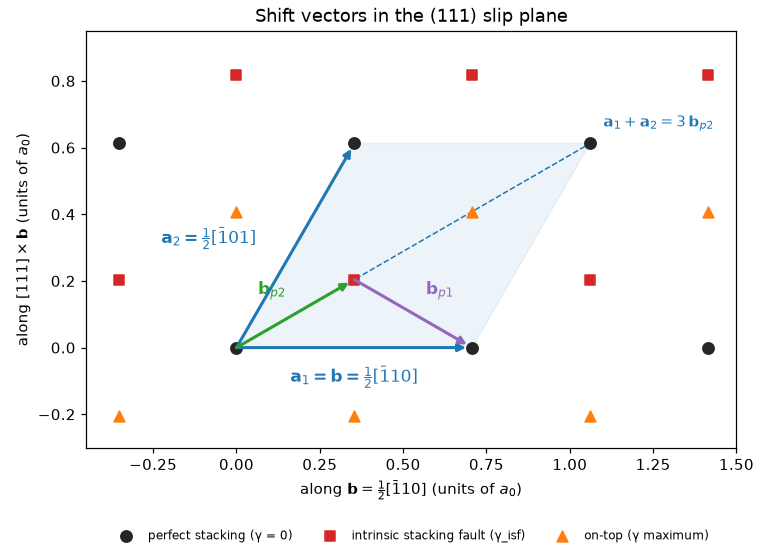

*Shift vectors in the (111) plane, seen from above. Each point is a rigid shift of the upper half-crystal: black circles are lattice translations (perfect stacking, γ = 0),
red squares give the intrinsic stacking fault, orange triangles the on-top position (γ maximum). The shaded rhombus spanned by $\mathbf a_1$ and $\mathbf a_2$ is the area covered by the fault-map grid.

**Script contract - `gsf.in`** (called once per shift)

| in | out |
|---|---|
| `data_file`, `out_file` | `E_total` [eV]; relaxed slab in `out_file` |

The slab is periodic in-plane and has free surfaces along z (`boundary p p s`). Atoms are relaxed along z only (`fix setforce 0 0 NULL`).

In [ ]:
NUM_A1 = NUM_A2 = 12       # γ-surface grid (12x12 = 144 small relaxations); multiple of 6 so 1/6, 1/3, 2/3 are on-grid
SLAB_MINWIDTH = 40.0       # Å, slab thickness normal to (111)

a1_uvw = b_uvw                     # 1/2[-110]
a2_uvw = 3 * bp2_uvw - b_uvw        # 1/2[-101]
assert np.allclose((a1_uvw + a2_uvw) / 3, bp2_uvw)
ucell = am.load('ase_Atoms', ucell_ase)                     # atomman copy for the defect builders (Sections 5, 7, 8)
sf = am.defect.StackingFault('1 1 1', ucell, a1vect_uvw=a1_uvw, a2vect_uvw=a2_uvw)
sf.surface(minwidth=SLAB_MINWIDTH, even=True)
print('slab atoms:', sf.system.natoms, '| fault area: %.3f Å^2' % sf.surfacearea)

In [ ]:
print(Path('scripts/gsf.in').read_text())

In [ ]:
a1s, a2s, Es = [], [], []
for a1, a2, system in sf.iterfaultmap(num_a1=NUM_A1, num_a2=NUM_A2):
    system.dump('ase_Atoms').write('work/gsf.data', format='lammps-data')
    L = LAMMPS(cmdargs=['-screen', 'none',
                        '-var', 'potential_file', 'potential.mod',
                        '-var', 'data_file', 'work/gsf.data',
                        '-var', 'out_file', f'work/gsf_{a1:.3f}_{a2:.3f}.data'])   # one relaxed slab per shift
    L.file('scripts/gsf.in')
    a1s.append(a1); a2s.append(a2); Es.append(L.extract_variable('E_total'))
    L.close()

E0 = Es[0]                               # (a1, a2) = (0, 0): perfect stacking
assert a1s[0] == 0 and a2s[0] == 0
E_gsf = (np.array(Es) - E0) / sf.surfacearea      # eV/Å^2
gamma = am.defect.GammaSurface(a1vect=a1_uvw, a2vect=a2_uvw, box=ucell.box,
                               a1=a1s, a2=a2s, E_gsf=E_gsf)

**From the grid to a continuous γ-surface.** LAMMPS gives the energy only at the 12×12 grid points. The smooth surface and curves below,
and every value read with `gamma.E_gsf(a1=..., a2=...)`, come from a radial-basis-function (RBF) fit that atomman passes through these points; the plots below mark the computed grid points as dots.

In [ ]:
fig = gamma.E_gsf_surface_plot(energyperarea_unit='mJ/m^2')
x, y = gamma.a12_to_xy(np.array(a1s), np.array(a2s))         # grid points in the plot's Cartesian frame (Å)
fig.axes[0].plot(x, y, 'o', ms=4, mfc='white', mec='k', mew=0.5, ls='none', label='LAMMPS (grid points)')
fig.axes[0].legend(loc='upper left')
fig = gamma.E_gsf_line_plot(vect=3 * bp2_uvw, energyperarea_unit='mJ/m^2')   # perfect -> ISF -> on-top -> perfect, along [-211]

In [ ]:
# Along b_p2 = (a1 + a2)/3 the fractional shifts are equal: a1 = a2 = s/3, with s the fraction of |b_p|.
# Both ends are energy minima (perfect crystal at s = 0, intrinsic fault at s = 1), so in between the energy must pass
# through a maximum: the unstable stacking fault, the barrier a leading partial has to cross.
s = np.linspace(0, 1, 201)
g_path = uc.get_in_units(gamma.E_gsf(a1=s / 3, a2=s / 3), 'mJ/m^2')                          # RBF fit
s_grid = np.arange(NUM_A1 // 3 + 1) * 3 / NUM_A1                                               # where the path crosses grid points
g_grid = uc.get_in_units(gamma.E_gsf(a1=s_grid / 3, a2=s_grid / 3), 'mJ/m^2')    # LAMMPS energies
assert g_path.argmax() < len(s) - 1, 'path ends at a maximum: this direction leads to the on-top position, not the ISF'
gamma_usf, s_usf = g_path.max(), s[g_path.argmax()]
gamma_isf = g_path[-1]

DFT_USF, DFT_ISF = 316.330, 173.422      # mJ/m²; Becker et al. (2011), Table 3 (DFT)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.axhline(DFT_USF, ls='--', c='tab:red', lw=1, label=r'DFT $\gamma_{usf}$')
ax.axhline(DFT_ISF, ls='--', c='tab:green', lw=1, label=r'DFT $\gamma_{isf}$')
ax.plot(s, g_path, label='RBF fit'); ax.plot(s_grid, g_grid, 'o', label='LAMMPS (grid points)')
ax.axhline(gamma_isf, ls=':', c='k', label=r'this potential $\gamma_{isf}$')
ax.set_ylim(top=1.15 * max(DFT_USF, gamma_usf)); ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1))
ax.set(xlabel=r'shift / $|b_p|$ along $b_{p2}$', ylabel=r'$\gamma$ (mJ/m$^2$)')
fig.tight_layout()
results.update(gamma_usf=gamma_usf, gamma_isf=gamma_isf)
print(f'γ_usf = {gamma_usf:.1f} mJ/m² at {s_usf:.2f} b_p  |  γ_isf = {gamma_isf:.1f} mJ/m²')
print('LAMMPS on the path:', '   '.join(f's={a:.2f}: {g:.1f}' for a, g in zip(s_grid, g_grid)), 'mJ/m²')

**Looking at the intrinsic stacking fault.** The slab is shown perfect and with the shift $\mathbf b_{p2}$ that creates the intrinsic fault, both after relaxation, coloured by CNA.
The intrinsic stacking fault changes the stacking from …ABCABC… to …ABC|BCA…: one ABC sequence loses a layer. This leaves two (111) layers with hcp coordination (red).
Atoms at the free surfaces of the slab are classed as *other* (white). For display only, the slab is repeated 4×4 in-plane.

In [ ]:
# Both slabs were already relaxed in the grid loop above: just read them back.
slabs = {}
for name, (f1, f2) in {'perfect': (0.0, 0.0), 'ISF': (1/3, 1/3)}.items():
    slab = ase.io.read(f'work/gsf_{f1:.3f}_{f2:.3f}.data', format='lammps-data')
    slab.pbc = (True, True, False)                   # free surfaces along z
    slabs[name] = slab.repeat((4, 4, 1))
render(list(slabs.values()), titles=list(slabs), modifiers=[CNA()], view='Front')

**Exploring all sampled configurations.** Every grid point was relaxed by LAMMPS in the loop above and saved as `work/gsf_<a1>_<a2>.data`.
The sliders select a grid point, in steps of $1/12$ of $\mathbf a_1$ and $\mathbf a_2$; the ▶ next to each slider animates the shift along that vector. The third ▶ moves along $\mathbf b_{p2}$, through the grid points $(k, k)$:
perfect $(0, 0)$ → intrinsic fault $(4, 4)$ → on-top $(8, 8)$ → perfect again (the grid repeats after 12).
Each slab is repeated 4×4 in-plane and coloured by CNA.

In [ ]:
# Read back every relaxed slab of the grid loop, together with its energy.
grid = {}
for a1, a2, E in zip(a1s, a2s, E_gsf):
    slab = ase.io.read(f'work/gsf_{a1:.3f}_{a2:.3f}.data', format='lammps-data')
    slab.pbc = (True, True, False)
    grid[round(a1 * NUM_A1), round(a2 * NUM_A2)] = (slab.repeat((4, 4, 1)), uc.get_in_units(E, 'mJ/m^2'))

p = pipeline(grid[0, 0][0], CNA())
scene = ovito.Scene()
scene.pipelines.append(p)
vp = Viewport(scene=scene.scene_root, type=Viewport.Type.Front)
vp.zoom_all()
viewer = ovito.gui.create_ipywidget(vp, layout=ipywidgets.Layout(width='100%', height='450px'))

slider_a1 = ipywidgets.IntSlider(value=0, min=0, max=NUM_A1 - 1, description=f'a1 / {NUM_A1}')
slider_a2 = ipywidgets.IntSlider(value=0, min=0, max=NUM_A2 - 1, description=f'a2 / {NUM_A2}')
play_a1 = ipywidgets.Play(value=0, min=0, max=NUM_A1 - 1, interval=400, repeat=True)
play_a2 = ipywidgets.Play(value=0, min=0, max=NUM_A2 - 1, interval=400, repeat=True)
ipywidgets.link((play_a1, 'value'), (slider_a1, 'value'))   # linked in Python: jslink (browser-only) does nothing on Colab
ipywidgets.link((play_a2, 'value'), (slider_a2, 'value'))   # linked in Python: jslink (browser-only) does nothing on Colab

# Path along b_p2 = (a1 + a2) / 3: grid point (k, k) is the shift (3k / NUM_A1) b_p2
assert NUM_A1 == NUM_A2
play_bp2 = ipywidgets.Play(value=0, min=0, max=NUM_A1 - 1, interval=400, repeat=True)
def along_bp2(change):
    with slider_a1.hold_trait_notifications(), slider_a2.hold_trait_notifications():   # move both before redrawing
        slider_a1.value = slider_a2.value = change['new']
play_bp2.observe(along_bp2, 'value')
info = ipywidgets.Label()

def show(change=None):
    atoms, g = grid[slider_a1.value, slider_a2.value]
    data = ase_to_ovito(atoms)
    data.cell.vis.enabled = True
    p.source.data = data                 # swap the structure, keep the pipeline (CNA) and the camera
    viewer.refresh()
    info.value = f'shift = ({slider_a1.value}/{NUM_A1}) a1 + ({slider_a2.value}/{NUM_A2}) a2    γ = {g:.1f} mJ/m²'

slider_a1.observe(show, 'value')
slider_a2.observe(show, 'value')
show()
ipywidgets.VBox([ipywidgets.HBox([play_a1, slider_a1]), ipywidgets.HBox([play_a2, slider_a2]),
                 ipywidgets.HBox([play_bp2, ipywidgets.Label('along b_p2: (k, k)')]), info, viewer])

## 6. Equilibrium partial separation
The two Shockley partials repel elastically and are pulled together by the **intrinsic** stacking fault between them. They settle where the two forces balance.

The partials repel with a force per unit length $\mu\,b^2/(12\pi d)$.
Setting this equal to the stacking-fault energy $\gamma_{sf}$ (here $\gamma_{sf} = \gamma_{isf}$ from Section 5) gives
$$d_{sf} = \frac{\mu b^2}{12\pi\gamma_{sf}}$$
with $\mu$ the slip-system shear modulus from Section 4.


In [ ]:
def d_sf(mu_GPa, b, g_mJ):
    return uc.set_in_units(mu_GPa, 'GPa') * b**2 / (12 * np.pi * uc.set_in_units(g_mJ, 'mJ/m^2'))

results['d_sf_iso'] = d_sf(mu, b, gamma_isf)
print(f"d_sf = {results['d_sf_iso']:6.1f} Å   (all characters)")

## 7. Periodic array of dislocations (PAD)
Section 6 predicted that the edge dislocation splits into two Shockley partials with a stacking fault between them. Here we insert it atom by atom and let the potential decide.

**The cell.** The slip plane (111) is horizontal: $x$ along $\mathbf b=\tfrac{a_0}{2}[\bar110]$, $z$ along the line $\boldsymbol\xi=[11\bar2]$, $y$ along the normal.
The cell is periodic in $x$ and $z$, so the line is infinite and repeats every $L_x$: a row of dislocations on one slip plane.
It has free surfaces in $y$; a periodic $y$ would require a second dislocation of opposite sign.

**The starting guess** (`periodicarray(linear=True)`). The upper half is slid over the lower half by an amount that drops linearly from $\mathbf b$ to 0 across the cell,
so the Burgers vector is spread over the whole slip plane. The slip adds one extra half-plane of atoms to the upper half:
to fit it, atomman shortens $L_x$ by $b/2$ and removes the atoms that land on top of each other.

**What the relaxation does.** At the start almost every column across the slip plane sits at a costly intermediate shift on the γ-surface (Section 5).
The atoms move to the nearest low-energy shifts: perfect stacking on the outside, the stacking fault in the middle. The two places where the shift jumps become the partial cores.
They repel elastically, the fault between them costs $\gamma_{isf}$ per unit area, and they stop at $d_{eq}$.
Starting smeared rather than from a compact core makes this fast and keeps the partials on the intended plane (La Rosa et al., *Acta Mater.* 301, 121561 (2025), App. A.3).

`base` is the same crystal without the dislocation; Section 9 uses it as the reference for the disregistry.

**Cell size.** 150 × 80 × 8 Å (about 10 700 atoms) runs in a few minutes on one core.

**Script contract - `pad.in`**

| in | out |
|---|---|
| `data_file`, `out_file`, `tol` [bar] (default 20), `max_cycles` (default 10), `traj_every` (default 0: no trajectory), `traj_file` | `E_total` [eV], `n_cycles`, residual stresses `pxx_res`, `pzz_res`, `pxz_res` [bar]; relaxed cell in `out_file`; with `traj_every` > 0, a frame every `traj_every` minimizer iterations in `traj_file` |

Each relaxation cycle has two stages. CG lets the box change shape until $\sigma_{xx}=\sigma_{zz}=\sigma_{xz}=0$, which removes the strain from inserting the dislocation.
FIRE then runs at fixed box and finishes moving the atoms where CG stalls on the flat core landscape. Since FIRE changes the stress a little, the pair repeats until all three stresses are below `tol`.

In [ ]:
PAD_AMIN, PAD_BMIN, PAD_CMIN = 150.0, 80.0, 8.0      # Å along x (m), y (n), z (ξ)

dislocation = am.defect.Dislocation(ucell, C, burgers=b_uvw, ξ_uvw=[1, 1, -2], slip_hkl=[1, 1, 1],
                                    m=[1, 0, 0], n=[0, 1, 0])
base, pad = dislocation.periodicarray(amin=PAD_AMIN, bmin=PAD_BMIN, cmin=PAD_CMIN, linear=True, return_base_system=True)
pad_ase  = pad.dump('ase_Atoms')                     # frame shifted by -pad.box.origin, see 0.6
base_ase = base.dump('ase_Atoms')
pad_ase.pbc = base_ase.pbc = (True, False, True)
print('PAD atoms:', len(pad_ase), '| cell (Å):', pad_ase.cell.lengths().round(2), '| base cell L_x (Å):', round(base.box.lx, 2))

In [ ]:
print(Path('scripts/pad.in').read_text())

In [ ]:
pad_ase.write('work/pad.data', format='lammps-data')
L = LAMMPS(cmdargs=['-screen', 'none',
                    '-var', 'potential_file', 'potential.mod',
                    '-var', 'data_file', 'work/pad.data',
                    '-var', 'out_file', 'work/pad_out.data',
                    '-var', 'traj_every', '100', '-var', 'traj_file', 'work/pad_traj.dump'])   # frames for the animation below
L.file('scripts/pad.in')
results['E_pad'] = L.extract_variable('E_total')
n_cycles = int(L.extract_variable('n_cycles'))
residual = {k: L.extract_variable(k) for k in ('pxx_res', 'pzz_res', 'pxz_res')}
L.close()
print(f'{n_cycles} relaxation cycles; residual stresses (bar):', {k: round(v, 1) for k, v in residual.items()})

pad_relaxed = ase.io.read('work/pad_out.data', format='lammps-data')
pad_relaxed.pbc = pad_ase.pbc
assert len(pad_relaxed) == len(base_ase)

**Before and after relaxation, defect atoms only.** Atoms classed as fcc by CNA, and all atoms more than 15 Å from the slip plane, are hidden.
As built, the disregistry changes slowly along the whole cell. Over a long stretch the two planes next to the slip plane are shifted by roughly half of $\mathbf b$,
which is close to the stacking-fault shift, so CNA already labels them hcp (red), but there are no distinct partials.
After relaxation the disregistry has gathered into two Shockley partials (cores in blue and white: bcc and other, which here are only CNA's labels for the distorted core atoms),
joined by a narrower ribbon of hcp atoms, which is the intrinsic stacking fault from Section 5. The view looks down the line direction $z$, zoomed in on the defect atoms.

**First estimate of $d_{eq}$: the width of the hcp ribbon,** from the first to the last hcp atom along $x$, counting only the hcp atoms within 5 Å of the slip plane
(so that a stray hcp atom elsewhere, e.g. at a surface, cannot stretch it). It is direct and intuitive, but rough: CNA assigns each atom to one class,
so the ribbon edges are only resolved to about one atomic spacing, and the partial cores (blue and white) are not counted, so it comes out shorter than the true separation.

In [ ]:
data = {'as built': pipeline(pad_ase, CNA()).compute(), 'relaxed': pipeline(pad_relaxed, CNA()).compute()}
y_slip = -pad.box.origin[1]                          # slip plane (y = 0 in atomman's frame)
hide = [ExpressionSelectionModifier(expression=f'StructureType == 1 || abs(Position.Y - {y_slip}) > 15'),
        DeleteSelectedModifier()]                    # keep only non-fcc atoms within 15 Å of the slip plane
render([pad_ase, pad_relaxed], titles=list(data), modifiers=[CNA(), *hide], view='Top', show_cell=False)

st = np.asarray(data['relaxed'].particles['Structure Type'])
pos = pad_relaxed.positions
ribbon = (st == CNA.Type.HCP) & (np.abs(pos[:, 1] - y_slip) < 5)   # hcp atoms on the two planes next to the slip plane
x_hcp = pos[ribbon, 0]
results['d_eq_PAD_cna'] = np.ptp(x_hcp) if len(x_hcp) else 0.0     # first to last hcp column (0 if the core does not split)
print(f"hcp ribbon width: {results['d_eq_PAD_cna']:.1f} Å ({len(x_hcp)} hcp atoms)")

**Animation: how the core splits.** The frames are the minimization in `pad.in` as it ran, one every 100 minimizer iterations
(plus the last iteration of each CG and FIRE run), from the linear start to the relaxed PAD. The view shows the dislocation and the two free surfaces
(non-fcc atoms, coloured by CNA) and hides the fcc bulk: pass `show_surfaces=False` to see only the dislocation, or `show_bulk=True` to draw the bulk see-through.
3 periods along the line direction are shown for a clearer view of the slip plane.
The iteration counter runs on through all cycles. Most of the splitting happens in the first CG run, i.e. in the first part of the animation;
the exact iteration numbers change from run to run.
Watch the hcp ribbon (red) shrink and the two partial cores (blue and white) form at its edges.

In [ ]:
traj = ase.io.read('work/pad_traj.dump', index=':', format='lammps-dump-text')
frames = []
for atoms in traj:
    atoms.pbc = pad_ase.pbc
    atoms.set_chemical_symbols(['Ni'] * len(atoms))   # a dump stores atom types, not elements
    frames.append(atoms.repeat((1, 1, 3)))            # 3 periods along the line direction z
labels = [f"minimizer iteration {atoms.info['timestep']}" for atoms in traj]
print(len(frames), 'frames')
animate(frames, labels, show_surfaces=True, show_bulk=False)

## 8. Critical resolved shear stress (CRSS)
The CRSS at 0 K (the Peierls stress) is the lowest resolved shear stress on the slip system at which the dislocation glides.
We apply the shear stress $\tau = \sigma_{xy}$ ($\mathbf m$ along $x$, $\mathbf n$ along $y$) to the relaxed PAD from Section 7 through the free surfaces: the atoms in a 10 Å layer at the top
get a force $+f$ along $x$, those in a 10 Å layer at the bottom $-f$, with
$$|f| = \frac{\tau\, L_x L_z}{N_{layer}}$$
(La Rosa et al. 2025, eq. A.3), so the total force on each layer is $\tau$ times its area.
$\tau$ is raised in steps of `dtau`, and the cell is relaxed at every step (CG with the cell relaxed, then FIRE), starting from the previous step.

Below the CRSS the dislocation settles in a nearby position and the cell only shears elastically.
Above it, the dislocation glides through the periodic cell, and every passage slides the top over the bottom by $\mathbf b$, so the minimizer can no longer converge.
The script stops at the first step where FIRE no longer converges within `fire_maxiter` iterations: that is the step at which the dislocation glides
(the same criterion as in F. Brunner's script). As a check, it also records the relative displacement of the two layers along $x$ (`slip`).
The CRSS is the mean of the last stress at which the dislocation is static and the first at which it glides (La Rosa et al.).
A more accurate value can be obtained with a finer scan between the last two stresses:
run `crss.in` again with `tau_start` = `tau_static` and a smaller `dtau`.

**Script contract - `crss.in`**

| in | out |
|---|---|
| `data_file` (relaxed PAD), `tau_start`, `dtau` [MPa], `n_steps`, `layer` [Å] (default 10), `fire_maxiter` (default 5000), `traj_every` (default 0), `table_file`, `dump_dir` | `tau_static`, `tau_glide`, `CRSS` [MPa]; per step: $\tau$, slip, FIRE iterations in `table_file`, atoms in `dump_dir/step_<i>.dump`; with `traj_every` > 0 the trajectory of each step (CG and FIRE) in `dump_dir/traj_<i>.dump` |

A step counts as gliding when FIRE has not converged after `fire_maxiter` iterations; static steps of this PAD converge in 50–1500 iterations.
For the animation below, the scan also writes the trajectory of every step (`traj_every`).

In [ ]:
print(Path('scripts/crss.in').read_text())

In [ ]:
DTAU, N_STEPS = 0.5, 40                            # MPa; the scan reaches 20 MPa

L = LAMMPS(cmdargs=['-screen', 'none',
                    '-var', 'potential_file', 'potential.mod',
                    '-var', 'data_file', 'work/pad_out.data',
                    '-var', 'dtau', str(DTAU),
                    '-var', 'n_steps', str(N_STEPS),
                    '-var', 'table_file', 'work/crss.txt',
                    '-var', 'dump_dir', 'work/crss',
                    '-var', 'traj_every', '100'])      # frames for the animation below
L.file('scripts/crss.in')
tau_static, tau_glide = L.extract_variable('tau_static'), L.extract_variable('tau_glide')
results['CRSS_MPa'] = L.extract_variable('CRSS')
L.close()
assert tau_glide > 0, f'no glide up to {N_STEPS * DTAU} MPa; increase DTAU or N_STEPS'
print(f"static at {tau_static:.2f} MPa, glides at {tau_glide:.2f} MPa  ->  CRSS = {results['CRSS_MPa']:.2f} MPa")

scan = np.loadtxt('work/crss.txt', ndmin=2)            # one line per step: tau, slip, FIRE iterations
tau, slip, n_fire = scan.T
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
ax1.semilogy(tau, np.abs(slip) + 1e-6, 'o-')
ax1.set(xlabel=r'$\tau$ (MPa)', ylabel=r'slip since $\tau = 0$ (Å)')
ax2.plot(tau, n_fire, 'o-')
ax2.set(xlabel=r'$\tau$ (MPa)', ylabel='FIRE iterations')
for ax in (ax1, ax2):
    ax.axvline(results['CRSS_MPa'], ls='--', c='k', label='CRSS')
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
fig.tight_layout(); plt.show()

**Animation: the CRSS scan.** The frames are the whole scan as it ran, step by step: for each stress, the CG and FIRE minimization,
one frame every 100 minimizer iterations (plus the last iteration of each run). The label gives the step, its stress and the iteration within the step.
In the static steps the structure hardly changes: the cell shears elastically by about $10^{-3}$ Å per MPa.
In the last step, at $\tau$ = `tau_glide`, FIRE stops at `fire_maxiter` without converging, which is how the glide is detected.
Within those iterations the dislocation moves only a few Å (the distance is printed below; atomic columns are $b/2$ = 1.24 Å apart):
watch the hcp ribbon shift along $x$ in the last frames. The view options are the same as in Section 7; with the surfaces shown, you can also follow the top and bottom layers on which the shear forces act.
As in Section 7, the iterations are steps of a minimizer, not time.

In [ ]:
frames, labels = [], []
for k, (tau_k, slip_k, n_fire_k) in enumerate(scan):
    state = 'glides' if k == len(scan) - 1 else 'static'
    for atoms in ase.io.read(f'work/crss/traj_{k}.dump', index=':', format='lammps-dump-text'):
        atoms.pbc = pad_ase.pbc
        atoms.set_chemical_symbols(['Ni'] * len(atoms))   # a dump stores atom types, not elements
        frames.append(atoms.repeat((1, 1, 3)))            # 3 periods along the line direction z
        labels.append(f"step {k} ({state}): τ = {tau_k:.2f} MPa, minimizer iteration {atoms.info['timestep']}")
print(f'{len(frames)} frames; in the gliding step the dislocation moved about {scan[-1, 1] / b * pad_relaxed.cell[0, 0]:.1f} Å along x')
animate(frames, labels, show_surfaces=True, show_bulk=False)

## 9. Disregistry
The disregistry is the relative displacement of the two atomic planes that bound the slip plane, $\boldsymbol\delta(x) = \mathbf u_{above}(x) - \mathbf u_{below}(x)$,
measured against the perfect crystal `base`. Far to one side of the dislocation $\boldsymbol\delta = \mathbf b$, far to the other side $\boldsymbol\delta = 0$.

Each Shockley partial carries half of it. With $\mathbf b_p$ at 30° to $\mathbf b$, a partial has
* an **edge** component (along $\mathbf b$, $x$): $|\mathbf b_p|\cos 30° = b/2$,
* a **screw** component (along $\boldsymbol\xi$, $z$): $\pm|\mathbf b_p|\sin 30° = \pm b_p/2$, with opposite signs for the two partials.

So $\delta_x$ falls from $b$ to 0 in two steps of $b/2$, one at each partial, and $\delta_z$ is non-zero only between the partials, where it reaches $b_p/2$ in magnitude if the fault is wide enough.
We take the centre of each partial as the point where $\delta_x$ is halfway through its step ($3b/4$ and $b/4$): a third estimate of $d_{eq}$.

In [ ]:
base_am, pad_relaxed_am = am.load('ase_Atoms', base_ase), am.load('ase_Atoms', pad_relaxed)   # same frame and atom order
x_dis, dis = am.defect.disregistry(base_am, pad_relaxed_am, m=[1, 0, 0], n=[0, 1, 0], planepos=[0, y_slip, 0])

edge_p, screw_p = b / 2, bp / 2                      # components of one partial (Å)
x_p1 = np.interp(-0.75 * b, -dis[:, 0], x_dis)       # δx falls monotonically, so interpolate x(δx)
x_p2 = np.interp(-0.25 * b, -dis[:, 0], x_dis)
results['d_eq_disregistry'] = abs(x_p2 - x_p1)
k = np.argmax(np.abs(dis[:, 2]))
print(f'expected per partial: edge {edge_p:.3f} Å, screw ±{screw_p:.3f} Å')
print(f'largest |δz| = {abs(dis[k, 2]):.3f} Å at x = {x_dis[k]:.1f} Å, where δx = {dis[k, 0]:.3f} Å')
print(f"partial separation from δx: {results['d_eq_disregistry']:.1f} Å, "
      f"hcp ribbon: {results['d_eq_PAD_cna']:.1f} Å, Section 6: {results['d_sf_iso']:.1f} Å")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_dis, dis[:, 0], 'o-', ms=3, label=r'$\delta_x$ (edge)')
ax.plot(x_dis, dis[:, 2], 's-', ms=3, label=r'$\delta_z$ (screw)')
ax.plot(x_dis, dis[:, 1], '^-', ms=3, label=r'$\delta_y$ (normal)')
for v in (b, edge_p, 0.0):
    ax.axhline(v, ls=':', c='C0', lw=0.8)
for v in (screw_p, -screw_p):
    ax.axhline(v, ls=':', c='C1', lw=0.8)
for xp in (x_p1, x_p2):
    ax.axvline(xp, ls='--', c='k', lw=0.8)
ax.set(xlabel='x (Å)', ylabel='disregistry (Å)',
       title=f"relaxed PAD: partials {results['d_eq_disregistry']:.1f} Å apart (dashed)")
ax.set_xlim(x_p1 - 40, x_p2 + 40)
ax.legend()
plt.tight_layout(); plt.show()

Dotted lines mark the expected values: $b$, $b/2$ and 0 for $\delta_x$, and $\pm b_p/2$ for $\delta_z$.
The edge plateau at $b/2$ between the partials is well defined. The screw component stays somewhat below $b_p/2$:
the two partials are only a few core widths apart, so their screw parts overlap and partly cancel.

## Summary

In [ ]:
POTENTIAL_NAME = 'Mishin_2004'   # label of this run: one results file per potential
results['potential'] = POTENTIAL_NAME
out = Path(f'results_{POTENTIAL_NAME}.json')
out.write_text(json.dumps({k: (float(v) if isinstance(v, (np.floating, float, int)) and v is not None else v)
                           for k, v in results.items()}, indent=2))
for k, v in results.items():
    print(f'{k:18s} {v:.4g}' if isinstance(v, (float, np.floating)) else f'{k:18s} {v}')